In [140]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [141]:
def norm_radian(radian, pi=pi):
    radian = radian % (2 * pi)
    return radian if abs(radian) <= pi else radian - (1 if radian >= 0 else -1) * 2 * pi

In [142]:
# Parameters
size = 100           # Number of samples
mean = pi / 2            # Center of the distribution
std = 0.25          # Standard deviation (adjust for spread)
low, high = 0, pi

# Generate normal distribution and clip to range
radians = np.random.normal(loc=mean, scale=std, size=size)
radians = np.clip(radians, low, high)

for i in range(len(radians)):
    radians[i] += pi / 2
    if radians[i] > pi:
        radians[i] -= 2 * pi

In [143]:
# Choose number of bins (adjust as needed)
bins = 50

# Compute histogram
hist, bin_edges = np.histogram(radians, bins=bins)
print(hist)

# Find the index of the bin with the most values
max_bin_index = np.argmax(hist)

# Get the range (left and right edge) of the mode bin
mode_range = (bin_edges[max_bin_index], bin_edges[max_bin_index + 1])
mode = abs(mode_range[1] + mode_range[0]) / 2

print("Mode range:", mode_range)
print("Mode:", mode)
print("Number of values in this range:", hist[max_bin_index])

[21 11  8  6  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  7 10
 13 21]
Mode range: (-3.1407295137696725, -3.015105893347634)
Mode: 3.0779177035586534
Number of values in this range: 21


Outlier indices (not within ±15° of mode): [2, 6, 7, 14, 16, 17, 18, 20, 26, 27, 29, 34, 38, 42, 48, 52, 54, 56, 57, 66, 68, 70, 73, 75, 77, 78, 79, 82, 84, 86, 89]


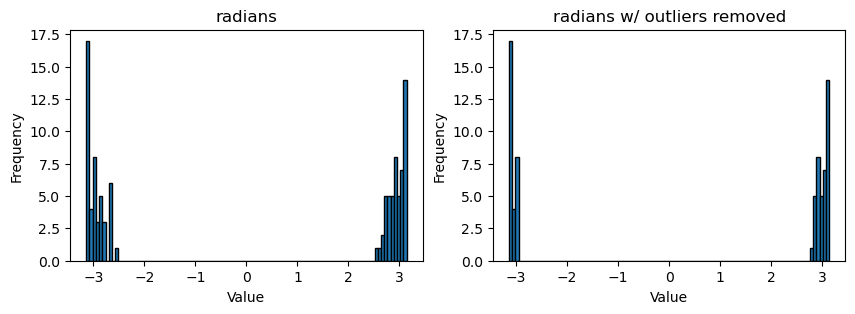

In [144]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(radians, bins=100, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('radians')

# 15 degrees in radians
threshold = 15 * np.pi / 180  # ≈ 0.2618

# Find indices where the absolute difference from the mode is greater than threshold
outlier_indices = [i for i, radian in enumerate(radians) if abs(norm_radian(radian - mode)) > threshold]
print("Outlier indices (not within ±15° of mode):", outlier_indices)

radians = [radians[i] for i in range(len(radians)) if i not in outlier_indices]

plt.subplot(1, 2, 2)
plt.hist(radians, bins=100, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('radians w/ outliers removed')
plt.show()